<a href="https://www.udea.edu.co">
    <img src="https://www.udea.edu.co/wps/wcm/connect/udea/2288a382-341c-41ee-9633-702a83d5ad2b/logosimbolo-horizontal-png.png?MOD=AJPERES&CVID=ljeSAX9" alt="Universidad de Antioquia Logo" width="200"/>
</a>


**SISTEMAS DE CONTROL CONTÍNUO**

- Prof. Hernán Felipe García Arias, PhD
- Prof. Andrés Felipe López García, PhD
- Facultad de Ingeniería
- Ingeniería Electrónica
- UdeA - 2026

<h2>TCLab Plotter</h2>
<p>Cuando se trabaja en un Jupyter Notebook, puede emplearse un <code>Plotter</code> junto con el <code>Historian</code>:</p>
<pre><code>import tclab
from tclab import Historian, Plotter

lab = tclab.TCLab()
h = Historian(lab)
p = Plotter(h, tfinal)</code></pre>
<p>Donde <code>lab</code> es una instancia de <code>TCLab</code> y el parámetro opcional <code>tfinal</code> define la escala inicial del eje de tiempo. Cada llamada a <code>p.update()</code> actualizará automáticamente tanto el historizador como la gráfica.</p>

In [1]:
!pip install tclab --upgrade


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: C:\Users\SANTIAGO\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


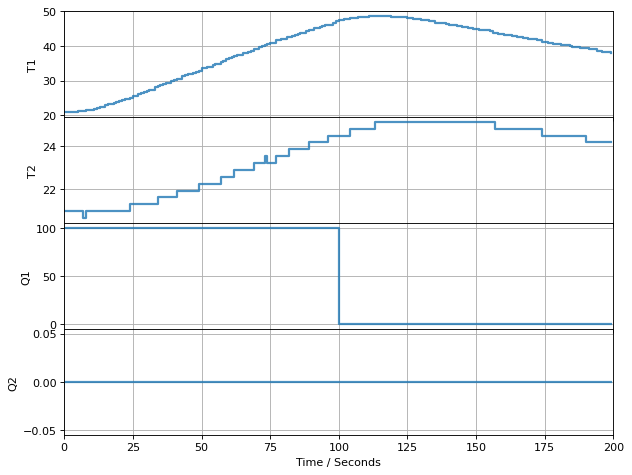

TCLab Model disconnected successfully.


In [2]:
%matplotlib notebook
from tclab import TCLab, clock, Historian, Plotter, setup

TCLab = setup(connected=False, speedup=10)

with TCLab() as lab:
    h = Historian(lab.sources)
    p = Plotter(h, twindow=200)
    for t in clock(200):
        lab.Q1(100 if t < 100 else 0)
        p.update(t)

<h2>Especificando la distribución de gráficos</h2>
<p>Al crear un <code>Plotter</code>, puede especificarse el diseño (layout) de los ejes mediante una tupla de tuplas. Cada tupla de primer nivel crea un nuevo eje, y cada elemento interior se plotea en ese mismo eje.</p>
<pre><code># Ejemplo de layout con dos ejes:
# - Primer eje: T1 y T2
# - Segundo eje: Q1 y Q2
p = Plotter(h, tfinal, layout=(('T1','T2'), ('Q1','Q2')))</code></pre>

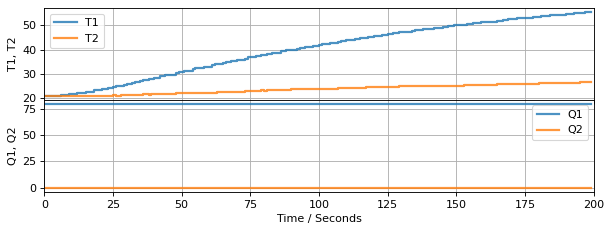

TCLab Model disconnected successfully.
50.1700234413147 seconds


In [4]:
%matplotlib notebook
from tclab import setup
from tclab import Historian, Plotter, clock
import time

tic = time.time()
TCLab = setup(connected=False, speedup=10)

with TCLab() as lab:
    h = Historian(lab.sources)
    p = Plotter(h, 200, layout=(('T1', 'T2'), ('Q1', 'Q2')))
    for t in clock(200):
        lab.U1 = 80
        p.update(t)
toc = time.time()

print(toc-tic, 'seconds')